<a href="https://colab.research.google.com/github/Mukundan-T/seqADAGE/blob/master/Py/muk_transfer_learning/filtering/Mukundan_sa_filt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S. aureus - Filtering

### By: Mukundan Thanigaivelan

#### July 24, 2026

In this notebook, we filter S. aureus genes and samples to roughly obtain a normal distribution of our gene expression for inputting into the Denoising AutoEncoder (DAE).

The data have already been log-transformed and 0-1 scaled.

## 1. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

Cloning into 'seqADAGE'...
remote: Enumerating objects: 668, done.
remote: Counting objects: 100% (142/142), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 668 (delta 100), reused 32 (delta 32), pack-reused 526 (from 2)
Receiving objects: 100% (668/668), 54.42 MiB | 40.95 MiB/s, done.
Resolving deltas: 100% (350/350), done.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning/filtering

/content/seqADAGE/Py/muk_transfer_learning/filtering


In [3]:
!pip install -qq seaborn pydeseq2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.5/187.5 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 128.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 147.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 10.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

## 2. Loading classes & modules

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [7]:
# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Miscellaneous
import time
import re
import tensorflow as tf
from pydeseq2.preprocessing import deseq2_norm

In [8]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 3. Data filtering

Here we are looking at S. aureus genes in the strain USA300, with expression that has been log transformed and scaled to be between 0 and 1.

### Preparation

In [9]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sapg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [10]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 8961 genes (features) and 3737 samples


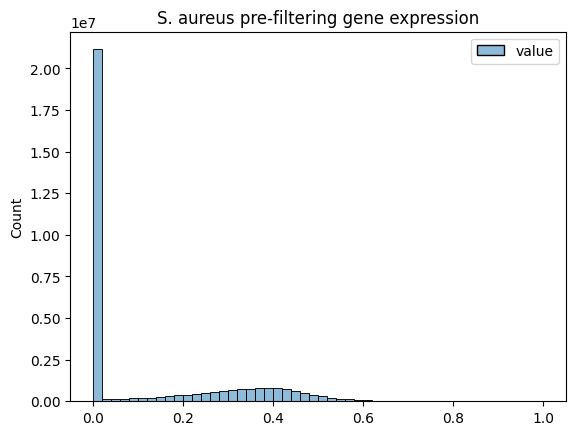

In [140]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)
plt.title("S. aureus pre-filtering gene expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_initial_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [12]:
# That's a lot of zeroes.. what percent?
print(f"{int(((all_comp == 0).sum().sum() / all_comp.size) * 100)}% of this compendium is zero.")

63% of this compendium is zero.


### Keep genes in USA300

In [13]:
# Load in gene presence tables
gpa = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sa_gene_presence_absence.csv', index_col = 0)
gpa.head()

,Non-unique Gene name,Annotation,No. isolates,No. sequences,Avg sequences per isolate,Genome Fragment,Order within Fragment,Accessory Fragment,Accessory Order with Fragment,QC,...,GCF_003052445.1,GCF_008244705.1,GCF_014857975.1,GCF_015475575.1,GCF_016916755.1,GCF_016916765.1,GCF_021284565.1,GCF_022832775.1,GCF_023278065.1,pandb_bacteria_1280
Gene,,,,,,,,,,,,,,,,,,,,,
WP_001294626.1,NaN,PH domain-containing protein,18,18,1,3405,4175,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_880,807c21e70fe3ee94f20b18028164a770_4511,e842c5db9e426c42b31bc4ac5dc193b7_5382,8e9ec6dd6361039c005aea98ba7304d1_4499,e749d233e3a4f981eef508a8913d8c41_5469,615df8abf0557b1242418123747d6b3a_6430,544965d78f6d5c49ee9e7adaf7bd009d_5326,a6d7098b7ef38ff9806fb130a5f01e95_4238,7930e79367e590eb33847b13d273fa6e_4034,pandb_bacteria_1280_01963
WP_001287088.1,NaN,hypothetical protein,18,18,1,3405,4174,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_878,807c21e70fe3ee94f20b18028164a770_4513,e842c5db9e426c42b31bc4ac5dc193b7_5380,8e9ec6dd6361039c005aea98ba7304d1_4501,e749d233e3a4f981eef508a8913d8c41_5467,615df8abf0557b1242418123747d6b3a_6428,544965d78f6d5c49ee9e7adaf7bd009d_5328,a6d7098b7ef38ff9806fb130a5f01e95_4240,7930e79367e590eb33847b13d273fa6e_4036,pandb_bacteria_1280_01964
WP_000379888.1,NaN,L-threonylcarbamoyladenylate synthase,18,18,1,3405,4125,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_791,807c21e70fe3ee94f20b18028164a770_4598,e842c5db9e426c42b31bc4ac5dc193b7_5295,8e9ec6dd6361039c005aea98ba7304d1_4586,e749d233e3a4f981eef508a8913d8c41_5382,615df8abf0557b1242418123747d6b3a_6343,544965d78f6d5c49ee9e7adaf7bd009d_5413,a6d7098b7ef38ff9806fb130a5f01e95_4325,7930e79367e590eb33847b13d273fa6e_4121,pandb_bacteria_1280_02008
WP_000792345.1,NaN,BCCT family transporter,18,18,1,3405,4307,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_1371,807c21e70fe3ee94f20b18028164a770_4771,e842c5db9e426c42b31bc4ac5dc193b7_2561,8e9ec6dd6361039c005aea98ba7304d1_4759,e749d233e3a4f981eef508a8913d8c41_2968,615df8abf0557b1242418123747d6b3a_3083,544965d78f6d5c49ee9e7adaf7bd009d_2551,a6d7098b7ef38ff9806fb130a5f01e95_4488,7930e79367e590eb33847b13d273fa6e_4294,pandb_bacteria_1280_02083
modA,NaN,molybdate ABC transporter substrate-binding pr...,18,18,1,3405,689,NaN,NaN,NaN,...,48bdb69ddbf0f0ac20d6a159eb106076_1707,807c21e70fe3ee94f20b18028164a770_4965,e842c5db9e426c42b31bc4ac5dc193b7_2757,8e9ec6dd6361039c005aea98ba7304d1_4951,e749d233e3a4f981eef508a8913d8c41_3162,615df8abf0557b1242418123747d6b3a_1096,544965d78f6d5c49ee9e7adaf7bd009d_2745,a6d7098b7ef38ff9806fb130a5f01e95_4686,7930e79367e590eb33847b13d273fa6e_4488,pandb_bacteria_1280_02167


In [14]:
# Get only gene names in strain columns
gpa_strains = gpa[
  ['GCF_000009645.1', 'GCF_000010465.1', 'GCF_000012045.1',
   'GCF_000013425.1', 'GCF_000756205.1', 'GCF_001456215.1',
   'GCF_001900185.1', 'GCF_002993865.1', 'GCF_003052445.1',
   'GCF_008244705.1', 'GCF_014857975.1', 'GCF_015475575.1',
   'GCF_016916755.1', 'GCF_016916765.1', 'GCF_021284565.1',
   'GCF_022832775.1', 'GCF_023278065.1', 'pandb_bacteria_1280'
  ]
]
gpa_strains.shape

(9935, 18)

In [15]:
# Concatenate all gene names into one string, filling in missing values with ''
gpa_strains['names_cat'] = gpa_strains.fillna('').agg(' '.join, axis=1)
gpa_strains['names_cat'].head()

Gene
WP_001294626.1    12b493b74dec297122c11824ed05ba01_4285 dd621b95...
WP_001287088.1    12b493b74dec297122c11824ed05ba01_4287 dd621b95...
WP_000379888.1    12b493b74dec297122c11824ed05ba01_4376 dd621b95...
WP_000792345.1    12b493b74dec297122c11824ed05ba01_4553 dd621b95...
modA              12b493b74dec297122c11824ed05ba01_4751 dd621b95...
Name: names_cat, dtype: str

In [16]:
# Add first_name_comp column
gpa_strains['first_name_comp'] = gpa_strains['names_cat'].str.split().apply(lambda x: x[0])
gpa_strains.head()

,GCF_000009645.1,GCF_000010465.1,GCF_000012045.1,GCF_000013425.1,GCF_000756205.1,GCF_001456215.1,GCF_001900185.1,GCF_002993865.1,GCF_003052445.1,GCF_008244705.1,GCF_014857975.1,GCF_015475575.1,GCF_016916755.1,GCF_016916765.1,GCF_021284565.1,GCF_022832775.1,GCF_023278065.1,pandb_bacteria_1280,names_cat,first_name_comp
Gene,,,,,,,,,,,,,,,,,,,,
WP_001294626.1,12b493b74dec297122c11824ed05ba01_4285,dd621b957428e8bac9d4e4836fc25ff0_4589,86be33626174370752bad760edea7ad6_4305,cds-YP_500787.1,9185d483bdb4535fed11f5978edaa119_4257,9ab1425e5eb2f9df6f6be6d193592bac_4100,53e0e900c609974f696d0a3fe29fcfc8_4424,7de8e2764d7131e46dce93449e724093_4475,48bdb69ddbf0f0ac20d6a159eb106076_880,807c21e70fe3ee94f20b18028164a770_4511,e842c5db9e426c42b31bc4ac5dc193b7_5382,8e9ec6dd6361039c005aea98ba7304d1_4499,e749d233e3a4f981eef508a8913d8c41_5469,615df8abf0557b1242418123747d6b3a_6430,544965d78f6d5c49ee9e7adaf7bd009d_5326,a6d7098b7ef38ff9806fb130a5f01e95_4238,7930e79367e590eb33847b13d273fa6e_4034,pandb_bacteria_1280_01963,12b493b74dec297122c11824ed05ba01_4285 dd621b95...,12b493b74dec297122c11824ed05ba01_4285
WP_001287088.1,12b493b74dec297122c11824ed05ba01_4287,dd621b957428e8bac9d4e4836fc25ff0_4591,86be33626174370752bad760edea7ad6_4307,cds-YP_500788.1,9185d483bdb4535fed11f5978edaa119_4259,9ab1425e5eb2f9df6f6be6d193592bac_4102,53e0e900c609974f696d0a3fe29fcfc8_4426,7de8e2764d7131e46dce93449e724093_4477,48bdb69ddbf0f0ac20d6a159eb106076_878,807c21e70fe3ee94f20b18028164a770_4513,e842c5db9e426c42b31bc4ac5dc193b7_5380,8e9ec6dd6361039c005aea98ba7304d1_4501,e749d233e3a4f981eef508a8913d8c41_5467,615df8abf0557b1242418123747d6b3a_6428,544965d78f6d5c49ee9e7adaf7bd009d_5328,a6d7098b7ef38ff9806fb130a5f01e95_4240,7930e79367e590eb33847b13d273fa6e_4036,pandb_bacteria_1280_01964,12b493b74dec297122c11824ed05ba01_4287 dd621b95...,12b493b74dec297122c11824ed05ba01_4287
WP_000379888.1,12b493b74dec297122c11824ed05ba01_4376,dd621b957428e8bac9d4e4836fc25ff0_4676,86be33626174370752bad760edea7ad6_4392,cds-YP_500833.1,9185d483bdb4535fed11f5978edaa119_4344,9ab1425e5eb2f9df6f6be6d193592bac_4191,53e0e900c609974f696d0a3fe29fcfc8_4511,7de8e2764d7131e46dce93449e724093_4562,48bdb69ddbf0f0ac20d6a159eb106076_791,807c21e70fe3ee94f20b18028164a770_4598,e842c5db9e426c42b31bc4ac5dc193b7_5295,8e9ec6dd6361039c005aea98ba7304d1_4586,e749d233e3a4f981eef508a8913d8c41_5382,615df8abf0557b1242418123747d6b3a_6343,544965d78f6d5c49ee9e7adaf7bd009d_5413,a6d7098b7ef38ff9806fb130a5f01e95_4325,7930e79367e590eb33847b13d273fa6e_4121,pandb_bacteria_1280_02008,12b493b74dec297122c11824ed05ba01_4376 dd621b95...,12b493b74dec297122c11824ed05ba01_4376
WP_000792345.1,12b493b74dec297122c11824ed05ba01_4553,dd621b957428e8bac9d4e4836fc25ff0_4849,86be33626174370752bad760edea7ad6_4565,cds-YP_500912.1,9185d483bdb4535fed11f5978edaa119_4509,9ab1425e5eb2f9df6f6be6d193592bac_4358,53e0e900c609974f696d0a3fe29fcfc8_4687,7de8e2764d7131e46dce93449e724093_4737,48bdb69ddbf0f0ac20d6a159eb106076_1371,807c21e70fe3ee94f20b18028164a770_4771,e842c5db9e426c42b31bc4ac5dc193b7_2561,8e9ec6dd6361039c005aea98ba7304d1_4759,e749d233e3a4f981eef508a8913d8c41_2968,615df8abf0557b1242418123747d6b3a_3083,544965d78f6d5c49ee9e7adaf7bd009d_2551,a6d7098b7ef38ff9806fb130a5f01e95_4488,7930e79367e590eb33847b13d273fa6e_4294,pandb_bacteria_1280_02083,12b493b74dec297122c11824ed05ba01_4553 dd621b95...,12b493b74dec297122c11824ed05ba01_4553
modA,12b493b74dec297122c11824ed05ba01_4751,dd621b957428e8bac9d4e4836fc25ff0_5043,86be33626174370752bad760edea7ad6_4759,cds-YP_501011.1,9185d483bdb4535fed11f5978edaa119_4699,9ab1425e5eb2f9df6f6be6d193592bac_4540,53e0e900c609974f696d0a3fe29fcfc8_4881,7de8e2764d7131e46dce93449e724093_4931,48bdb69ddbf0f0ac20d6a159eb106076_1707,807c21e70fe3ee94f20b18028164a770_4965,e842c5db9e426c42b31bc4ac5dc193b7_2757,8e9ec6dd6361039c005aea98ba7304d1_4951,e749d233e3a4f981eef508a8913d8c41_3162,615df8abf0557b1242418123747d6b3a_1096,544965d78f6d5c49ee9e7adaf7bd009d_2745,a6d7098b7ef38ff9806fb130a5f01e95_4686,7930e79367e590eb33847b13d273fa6e_4488,pandb_bacteria_128

In [17]:
# Get all the genes in the USA300 strain
usa300_genes = gpa_strains['first_name_comp'].loc[gpa_strains['GCF_002993865.1'].notna()]

# Keep only USA300 genes in the compendium
usa300_genes = usa300_genes[usa300_genes.isin(all_comp.index)]

len(usa300_genes)

2765

In [18]:
# Get the compendium for these genes
usa300_comp = all_comp.loc[usa300_genes]
usa300_comp.shape

(2765, 3737)

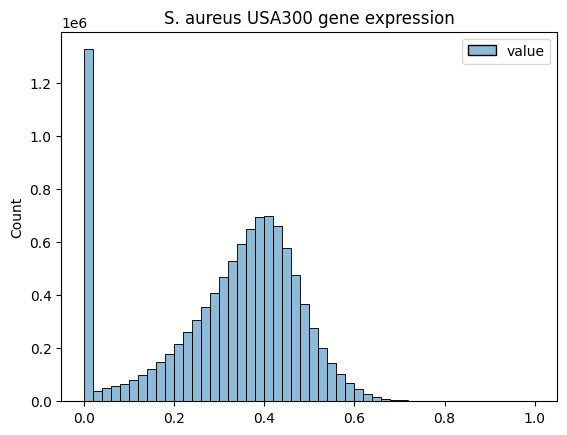

In [142]:
sns.histplot(pd.melt(usa300_comp), bins = 50)
plt.title("S. aureus USA300 gene expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_initial_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [141]:
print(
  f"There are {round(((usa300_comp == 0).sum().sum() / usa300_comp.size) * 100, 2)}% zeroes in the compendium."
)

There are 12.74% zeroes in the compendium.


### Gene-wise Filtering

In [20]:
# Get gene sample statistics
gene_stats = usa300_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
12b493b74dec297122c11824ed05ba01_4285,3737.0,0.420200,0.031521,0.279471,0.401637,0.417375,0.434090,0.611945
12b493b74dec297122c11824ed05ba01_4287,3737.0,0.316662,0.048477,0.000000,0.292055,0.317079,0.341392,0.517495
12b493b74dec297122c11824ed05ba01_4376,3737.0,0.378529,0.034187,0.187586,0.362492,0.381951,0.398913,0.581566
12b493b74dec297122c11824ed05ba01_4553,3737.0,0.380890,0.102447,0.000000,0.323830,0.393616,0.455001,0.607063
12b493b74dec297122c11824ed05ba01_4751,3737.0,0.410952,0.041978,0.238699,0.386147,0.411318,0.435825,0.612903


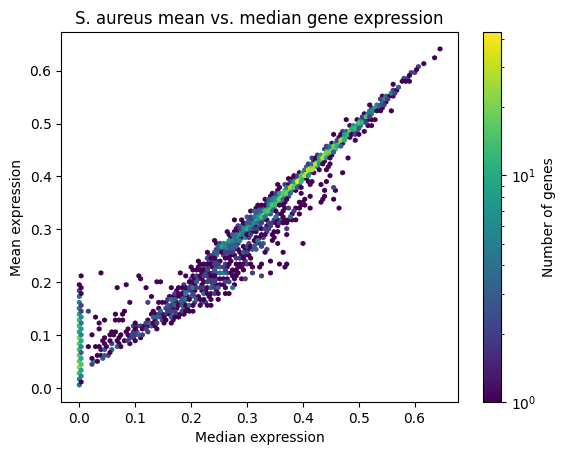

In [134]:
# Preliminary hexagonal binning log-scaled plot of mean versus median
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log'
)
plt.colorbar(label = 'Number of genes')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("S. aureus mean vs. median gene expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_mean_median_gene.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [105]:
# Empirically determined constant for thresholds
c1, c2 = 0.03, -0.03

# Cutoff lines to filter genes
x1 = np.linspace(0, 0.7, 200)
x2 = np.linspace(0, 0.7, 200)

y1 = x1 + c1
y2 = x2 + c2

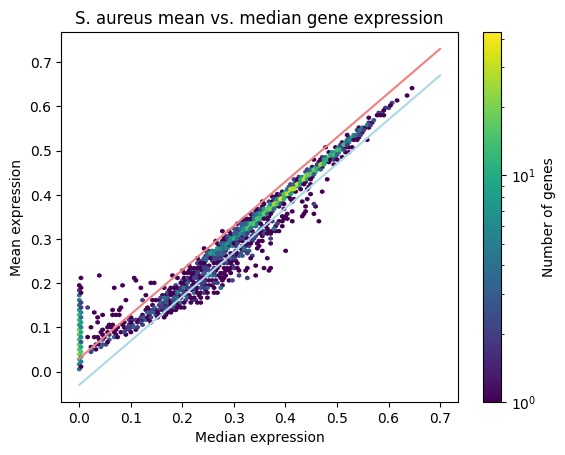

In [135]:
# Plot with threshold lines for filtering out genes
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log'
)
plt.colorbar(label = 'Number of genes')

plt.plot(x1, y1, color = 'lightcoral')
plt.plot(x2, y2, color = 'lightblue')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("S. aureus mean vs. median gene expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_mean_median_gene_thresholds.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [24]:
# Set thresholds to remove genes
threshold1 = gene_stats['50%'] + c1 # red
threshold2 = gene_stats['50%'] + c2 # blue

# Genes to remove
genes_to_rm = gene_stats[
  (gene_stats['mean'] > threshold1) |
  (gene_stats['mean'] < threshold2)
]
genes_to_rm.shape

(591, 8)

In [25]:
# Remove the genes
filtered_genes = usa300_comp.drop(index = genes_to_rm.index)
filtered_genes.shape

(2174, 3737)

In [26]:
# Get filtered gene stats
filtered_stats = filtered_genes.T.describe().T

Text(0.5, 1.0, 'Mean vs. median expression')

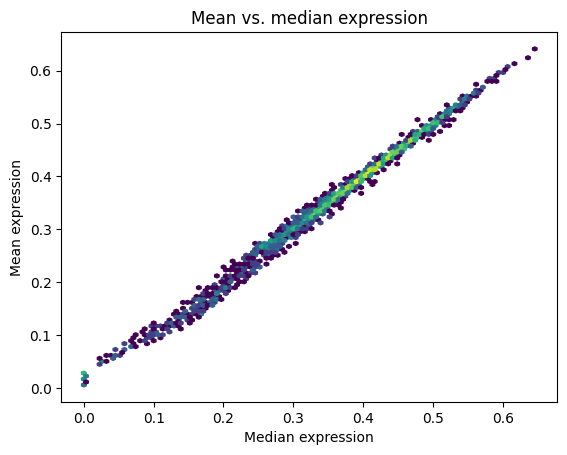

In [106]:
# Plot of gene expression mean versus median after filtering
plt.hexbin(
  x = filtered_stats['50%'],
  y = filtered_stats['mean'],
  bins = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

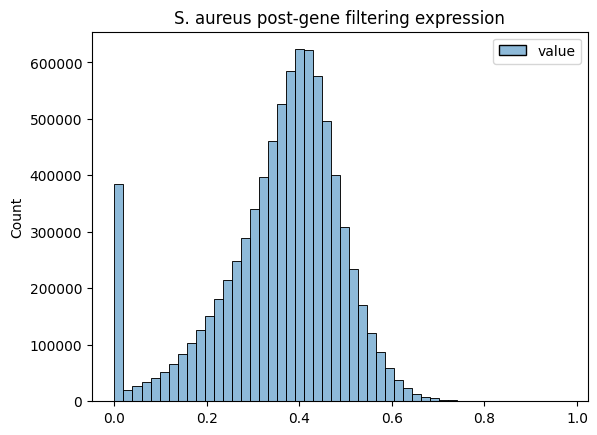

In [133]:
# Histogram of gene expression - getting better but needs work
sns.histplot(pd.melt(filtered_genes), bins=50)
plt.title("S. aureus post-gene filtering expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_genefilt_dist.png',
  dpi=300,
  bbox_inches='tight'
)

In [107]:
print(
  f"There are {round(((filtered_genes == 0).sum().sum() / filtered_genes.size) * 100, 2)}% zeroes in the compendium."
)

There are 4.68% zeroes in the compendium.


### Experiment-wise Filtering

In [29]:
# Get experiment sample statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
DRX011556,2174.0,0.358111,0.125289,0.0,0.293496,0.371170,0.434961,0.707659
DRX011557,2174.0,0.362853,0.123714,0.0,0.301695,0.375017,0.439086,0.784771
DRX011558,2174.0,0.361467,0.127111,0.0,0.302542,0.373261,0.439413,0.716095
DRX011559,2174.0,0.363593,0.128588,0.0,0.302885,0.381288,0.447463,0.694309
DRX011560,2174.0,0.354082,0.142570,0.0,0.299739,0.379094,0.445717,0.687590


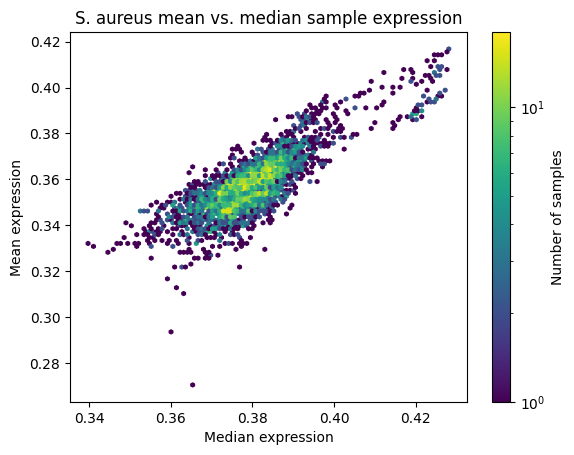

In [137]:
# Preliminary hexagonal binning log-scaled plot of median versus mean
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log'
)
plt.colorbar(label = 'Number of samples')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("S. aureus mean vs. median sample expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_mean_median_samp.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [102]:
# Empirically determined constant for threshold (optimal normality is -0.013, but only gives 359 samples)
c = -0.023

# Cutoff lines to filter samples
x = np.linspace(0.32, 0.42, 200)
y = x + c

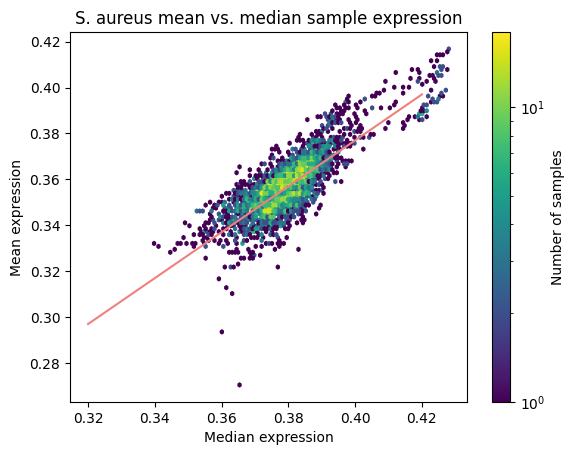

In [138]:
# Plot with threshold lines for filtering out samples
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log'
)
plt.colorbar(label = 'Number of samples')

plt.plot(x, y, color = 'lightcoral')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("S. aureus mean vs. median sample expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_mean_median_samp_threshold.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [93]:
# Set thresholds to remove samples
threshold1 = exp_stats['50%'] + c

# Samples to remove
exps_to_rm = exp_stats[exp_stats['mean'] < threshold1]
exps_to_rm.shape

(1556, 8)

In [94]:
# Remove the samples
filtered_df = filtered_genes.drop(columns = exps_to_rm.index)
filtered_df.shape

(2174, 2181)

In [95]:
# Get filtered stats
final_stats = filtered_df.describe().T

Text(0.5, 1.0, 'Mean vs. median expression')

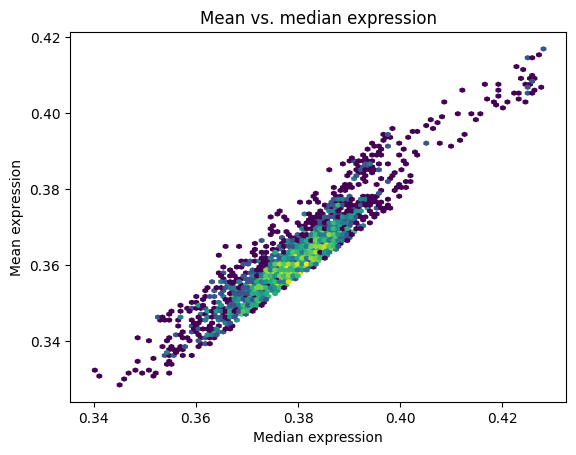

In [96]:
# Plot of sample expression median versus mean after filtering
plt.hexbin(
  x = final_stats['50%'],
  y = final_stats['mean'],
  bins = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. median expression")

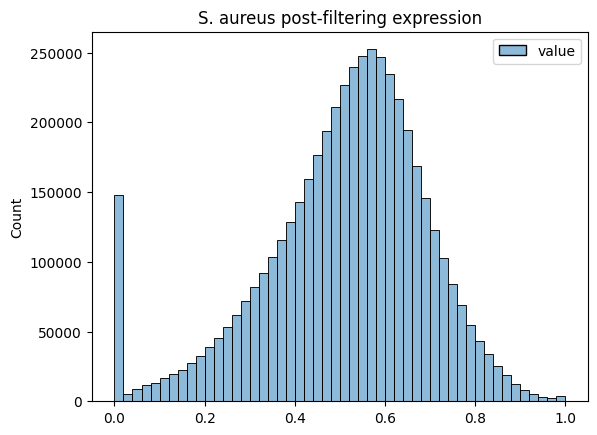

In [139]:
# Histogram of gene expression - somewhat better
sns.histplot(pd.melt(filtered_df), bins=50)
plt.title("S. aureus post-filtering expression")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_allfilt_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)

In [100]:
print(
  f"There are {round(((filtered_df == 0).sum().sum() / filtered_df.size) * 100, 2)}% zeroes in the compendium."
)

There are 3.09% zeroes in the compendium.


### Final Filtered Data

In [108]:
# Size of filtered genes and samples
filtered_df.shape

(2174, 2181)

## 4. Data post-processing and saving

We pull the raw counts for these filtered data and then normalize again through:

- Ratio of Medians
- Log-transform
- 0-1 scaling

Then, we save the data to a CSV.

In [109]:
raw_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/num_reads_saur_pan_genome_saur_comp_k15.csv',
  index_col = 0
)
raw_df.shape

(8961, 4234)

In [110]:
# Pull our filtered data in raw counts
raw_filt = raw_df.loc[filtered_df.index, filtered_df.columns]
raw_filt.head()

,DRX011556,DRX011557,DRX011558,DRX011559,DRX011561,DRX078101,DRX078113,DRX078114,DRX078115,DRX078116,...,SRX22637293,SRX22637294,SRX22637295,SRX22637296,SRX23205769,SRX23216295,SRX23216296,SRX23216297,SRX23271555,SRX23271562
12b493b74dec297122c11824ed05ba01_4285,171.000,253.000,175.00,141.000,97.000,272.198,225.000,367.887,404.067,373.129,...,835.000,873.000,919.000,2010.000,1256.00,2759.000,3010.00,3088.000,1636.000,1309.000
12b493b74dec297122c11824ed05ba01_4287,15.000,18.000,27.00,14.000,11.000,42.000,41.000,79.000,75.000,55.000,...,62.000,107.000,114.000,288.000,105.00,515.000,824.00,925.000,230.000,204.000
12b493b74dec297122c11824ed05ba01_4376,153.000,214.000,179.00,1934.000,1048.000,133.000,163.000,192.000,216.000,206.000,...,315.000,471.000,301.000,713.000,376.00,1308.000,1405.00,988.000,554.000,559.000
12b493b74dec297122c11824ed05ba01_4553,14.308,14.858,78.12,9.073,12.309,80.384,43.292,216.430,228.422,82.992,...,185.874,463.735,407.161,646.133,10684.82,1279.011,2598.21,2625.045,1165.918,1443.496
12b493b74dec297122c11824ed05ba01_4751,88.000,68.000,126.00,50.000,46.000,240.000,135.000,186.000,193.000,194.000,...,1189.000,298.000,394.000,1026.000,928.00,5747.000,3552.00,5103.000,768.000,751.000


In [111]:
# Ratio of Medians Scaling
norm_counts, size_factors = deseq2_norm(raw_filt.T)
norm_counts = norm_counts.T
norm_counts.head()

,DRX011556,DRX011557,DRX011558,DRX011559,DRX011561,DRX078101,DRX078113,DRX078114,DRX078115,DRX078116,...,SRX22637293,SRX22637294,SRX22637295,SRX22637296,SRX23205769,SRX23216295,SRX23216296,SRX23216297,SRX23271555,SRX23271562
12b493b74dec297122c11824ed05ba01_4285,1433.825028,2173.763653,1511.323400,1937.538952,2155.466957,2061.573852,1721.924400,1997.938611,2060.773438,2143.093991,...,644.010385,742.425192,707.213613,887.374939,1076.356279,1381.340670,1332.344125,1292.277022,2689.379653,2061.544988
12b493b74dec297122c11824ed05ba01_4287,125.774125,154.655122,233.175610,192.379754,244.434397,318.099699,313.772891,429.037042,382.505891,315.896565,...,47.818735,90.995986,87.728348,127.146260,89.982014,257.843583,364.734737,387.097230,378.091271,321.279738
12b493b74dec297122c11824ed05ba01_4376,1282.896078,1838.677557,1545.867935,26575.888887,23287.931661,1007.315713,1247.438565,1042.722938,1101.616966,1183.176226,...,242.950025,400.552423,231.633621,314.775289,322.221306,654.872633,621.908138,413.461690,910.706802,880.369479
12b493b74dec297122c11824ed05ba01_4553,119.971746,127.659211,674.654766,124.675822,273.522090,608.812528,331.313561,1175.398570,1164.970141,476.670686,...,143.359025,394.374051,313.329491,285.254841,9156.586862,640.358793,1150.069711,1098.537997,1916.623561,2273.362829
12b493b74dec297122c11824ed05ba01_4751,737.874868,584.252682,1088.152848,687.070550,1022.180206,1817.712564,1033.154640,1010.137846,984.315159,1114.253339,...,917.039937,253.428072,303.201484,452.958551,795.269607,2877.334117,1572.254596,2135.521258,1262.496072,1182.750409


In [112]:
# Log2 scaling
log_norm_counts = np.log2(norm_counts + 1)
log_norm_counts.head()

,DRX011556,DRX011557,DRX011558,DRX011559,DRX011561,DRX078101,DRX078113,DRX078114,DRX078115,DRX078116,...,SRX22637293,SRX22637294,SRX22637295,SRX22637296,SRX23205769,SRX23216295,SRX23216296,SRX23216297,SRX23271555,SRX23271562
12b493b74dec297122c11824ed05ba01_4285,10.486659,11.086643,10.562551,10.920754,11.074454,11.010230,10.750644,10.965018,11.009670,11.066152,...,9.333179,9.538044,9.468041,9.795025,10.073280,10.432897,10.380833,10.336816,11.393594,11.010210
12b493b74dec297122c11824ed05ba01_4287,6.986117,7.282209,7.871447,7.595293,7.939194,8.317863,8.298167,8.748317,8.583105,8.307868,...,5.609363,6.523499,6.471323,7.001648,6.507509,8.015937,8.514654,8.600274,8.566401,8.332170
12b493b74dec297122c11824ed05ba01_4376,10.326313,10.845237,10.595134,14.697885,14.507357,9.977732,10.285909,10.027523,10.106716,10.209668,...,7.930442,8.649445,7.861916,8.302754,8.336378,9.357272,9.282876,8.695095,9.832426,9.783603
12b493b74dec297122c11824ed05ba01_4553,6.918526,7.007411,9.400142,6.973563,8.100778,9.252222,8.376401,10.200161,10.187315,8.899873,...,7.173517,8.627074,8.296134,8.161156,13.160752,9.324988,10.168759,10.102682,10.905104,11.151247
12b493b74dec297122c11824ed05ba01_4751,9.529186,9.192916,10.088991,9.426413,9.998845,10.828702,10.014236,9.981764,9.944441,10.123156,...,9.842413,7.991114,8.248883,8.826417,9.637113,11.491018,10.619536,11.061048,10.303205,10.209149


In [113]:
# 0-1 scaling
log_01_norm_counts = (log_norm_counts - log_norm_counts.min()) / (log_norm_counts.max() - log_norm_counts.min())
log_01_norm_counts.head()

,DRX011556,DRX011557,DRX011558,DRX011559,DRX011561,DRX078101,DRX078113,DRX078114,DRX078115,DRX078116,...,SRX22637293,SRX22637294,SRX22637295,SRX22637296,SRX23205769,SRX23216295,SRX23216296,SRX23216297,SRX23271555,SRX23271562
12b493b74dec297122c11824ed05ba01_4285,0.584420,0.557289,0.581827,0.622937,0.623238,0.669530,0.651844,0.684461,0.692470,0.671130,...,0.420308,0.449050,0.464768,0.461728,0.503621,0.557623,0.541033,0.548747,0.641191,0.626386
12b493b74dec297122c11824ed05ba01_4287,0.389335,0.366053,0.433591,0.433248,0.446795,0.505808,0.503143,0.546090,0.539848,0.503848,...,0.252611,0.307126,0.317665,0.330051,0.325348,0.428440,0.443771,0.456560,0.482086,0.474028
12b493b74dec297122c11824ed05ba01_4376,0.575484,0.545154,0.583622,0.838391,0.816432,0.606744,0.623666,0.625941,0.635678,0.619187,...,0.357138,0.407215,0.385926,0.391384,0.416784,0.500132,0.483809,0.461594,0.553334,0.556602
12b493b74dec297122c11824ed05ba01_4553,0.385569,0.352239,0.517797,0.397783,0.455888,0.562626,0.507886,0.636717,0.640747,0.539752,...,0.323050,0.406162,0.407241,0.384709,0.657982,0.498406,0.529980,0.536318,0.613700,0.634409
12b493b74dec297122c11824ed05ba01_4751,0.531060,0.462097,0.555742,0.537698,0.562706,0.658491,0.607193,0.623084,0.625471,0.613940,...,0.443241,0.376221,0.404922,0.416069,0.481815,0.614177,0.553474,0.587195,0.579828,0.580812


In [114]:
# Save to a CSV file
log_01_norm_counts.to_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sa_usa300_lcn01_medmean_normal_muk.csv',
  index = True
)

In [143]:
# Verify that I can load the CSV back in here
filtered_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/sa_usa300_lcn01_medmean_normal_muk.csv',
  index_col = 0
)
filtered_df.shape

(2174, 2181)

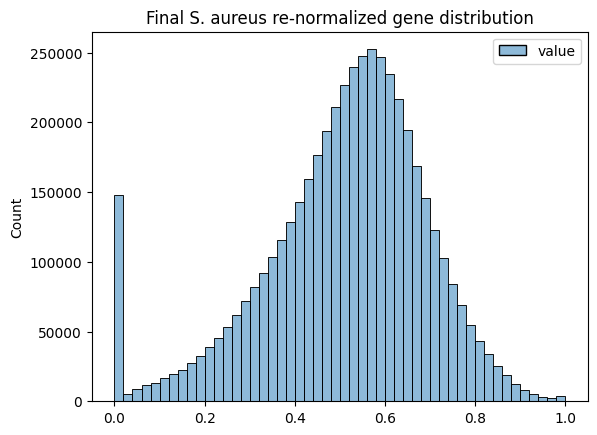

In [144]:
# Final data distribution
sns.histplot(pd.melt(filtered_df), bins = 50)
plt.title("Final S. aureus re-normalized gene distribution")

plt.savefig(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/figs/sa_usa300_final_renorm_dist.png',
  dpi = 300,
  bbox_inches = 'tight'
)